# Spotify Music Intelligence

## Machine Learning

### Objective

The objective of this notebook is to build machine learning models capable of predicting song popularity using Spotify audio features.

Models to be evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Evaluation Metrics

- MAE
- RMSE
- R² Score

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [2]:
songs = pd.read_csv("../data/raw/data.csv")

## Prepare Features

In [3]:
features = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "explicit",
    "year"
]

X = songs[features]
y = songs["popularity"]

## Split the Dataset

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Standardize the Features

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

Linear Regression serves as the baseline model.

It assumes a linear relationship between the audio features and song popularity.

In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.44,-0.46,-0.03,...,-0.03, 0.28,17.29]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,31.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[692.65,480.98,436.25,...,214.92,190.18,128.85]"


## Make Predictions

In [7]:
linear_predictions = linear_model.predict(X_test_scaled)

## Evaluate the Linear Regression Model

The model is evaluated using three common regression metrics:

- **Mean Absolute Error (MAE):** Measures the average prediction error. Lower values indicate better performance.
- **Root Mean Squared Error (RMSE):** Similar to MAE but penalizes larger prediction errors more heavily.
- **R² Score:** Indicates how well the model explains the variation in the target variable. Values closer to 1 represent better predictive performance.

In [8]:
mae = mean_absolute_error(
    y_test,
    linear_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")

Linear Regression
MAE : 7.98
RMSE: 10.73
R²  : 0.759


## Model 2: Decision Tree Regressor

A Decision Tree Regressor is trained to capture non-linear relationships between the audio features and song popularity. Unlike Linear Regression, Decision Trees do not require feature scaling.

In [9]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(
    X_train,
    y_train
)

tree_predictions = tree.predict(
    X_test
)

## Evaluate the Decision Tree Model

In [10]:
print("Decision Tree")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        tree_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            tree_predictions
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        tree_predictions
    )
)

Decision Tree
MAE: 9.218933911497857
RMSE: 13.67204515503558
R²: 0.609366617899185


## Model 3: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [12]:
forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest.fit(
    X_train,
    y_train
)

forest_predictions = forest.predict(
    X_test
)

## Evaluate the Random Forest Model

In [13]:
print("Random Forest")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        forest_predictions
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            forest_predictions
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        forest_predictions
    )
)

Random Forest
MAE: 6.74998255826699
RMSE: 9.549623633102623
R²: 0.8094210644690375


## Compare Model Performance

In [14]:
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        mean_absolute_error(y_test, linear_predictions),
        mean_absolute_error(y_test, tree_predictions),
        mean_absolute_error(y_test, forest_predictions)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test, linear_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions)),
        np.sqrt(mean_squared_error(y_test, forest_predictions))
    ],

    "R2":[
        r2_score(y_test, linear_predictions),
        r2_score(y_test, tree_predictions),
        r2_score(y_test, forest_predictions)
    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,7.982048,10.730850,0.759358
1,Decision Tree,9.218934,13.672045,0.609367
2,Random Forest,6.749983,9.549624,0.809421


## Visualize Model Performance

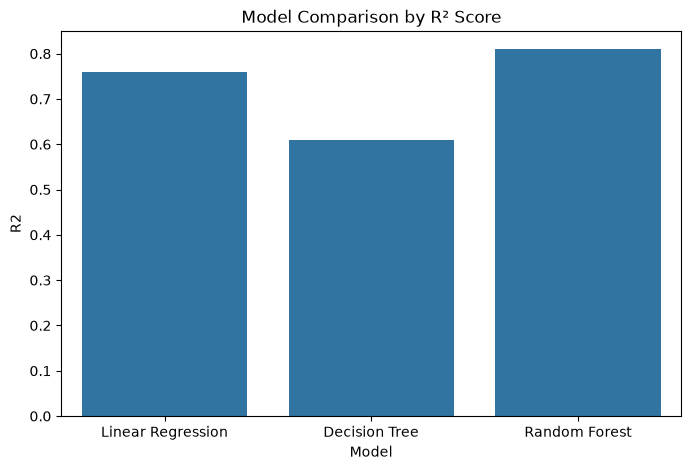

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison by R² Score")

plt.show()

## Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to predicting song popularity. This helps identify the most influential song characteristics.

In [16]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": forest.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
13,year,0.790616
11,duration_ms,0.025516
0,danceability,0.020362
3,loudness,0.020331
5,speechiness,0.019882
10,tempo,0.019121
8,liveness,0.018973
6,acousticness,0.018941
7,instrumentalness,0.018546
1,energy,0.018232


## Visualize Feature Importance

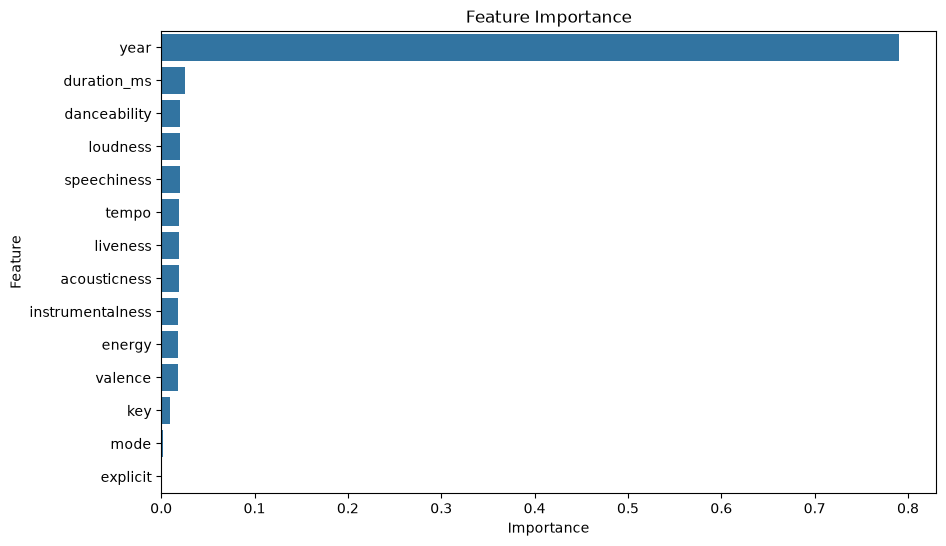

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## Conclusion

This project analyzed a large Spotify songs dataset to understand the factors that influence song popularity and to build machine learning models capable of predicting popularity using audio features.

The Exploratory Data Analysis (EDA) revealed several meaningful insights. Song popularity has generally increased over the years, with more recent releases achieving higher popularity than older songs. Correlation analysis showed that **year**, **energy**, and **loudness** have positive relationships with popularity, while **acousticness** has the strongest negative correlation. Scatter plots further indicated that no single audio feature alone determines a song's popularity, suggesting that popularity is influenced by the interaction of multiple characteristics rather than any one feature.

The distribution analysis showed that the dataset contains a diverse range of musical characteristics. Features such as **danceability** and **valence** are concentrated around moderate values, while **speechiness**, **instrumentalness**, and **liveness** are heavily skewed toward lower values. **Acousticness** displayed a bimodal distribution, indicating that many songs are either highly acoustic or minimally acoustic.

To predict song popularity, three regression models were trained and evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.

- **Linear Regression** achieved an **MAE of 7.98**, an **RMSE of 10.73**, and an **R² score of 0.759**, explaining approximately **75.9%** of the variation in song popularity.
- **Decision Tree Regressor** achieved an **MAE of 9.22**, an **RMSE of 13.67**, and an **R² score of 0.609**, making it the weakest-performing model among the three.
- **Random Forest Regressor** produced the best results with an **MAE of 6.75**, an **RMSE of 9.55**, and an **R² score of 0.809**, explaining approximately **80.9%** of the variation in song popularity while achieving the lowest prediction error.

Overall, the **Random Forest Regressor** outperformed both the Linear Regression and Decision Tree models, demonstrating that ensemble learning is more effective at capturing the complex, non-linear relationships between Spotify audio features and song popularity.

This project shows that while individual audio characteristics provide useful insights, combining multiple features through machine learning enables more accurate prediction of song popularity. Such predictive models can assist music streaming platforms, artists, and producers in understanding listener preferences and making more data-driven decisions.